# Telecom Customer Churn Analysis using Python (EDA)

## 📊 Dataset Overview
- Total Records: 7043 customers
- Total Features: 21 columns
- Target Variable: Churn (Yes/No)
- Dataset includes customer demographics, services, billing, and contract information.

## 📌 Project Introduction
This project performs Exploratory Data Analysis (EDA) on a telecom customer dataset to identify key factors influencing customer churn. The goal is to analyze customer behavior, services, contract types, and payment methods to generate actionable business insights for improving customer retention.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/Customer Churn.csv")

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 🧹 Data Cleaning & Preprocessing
- Replaced blank values in TotalCharges
- Converted TotalCharges to float
- Converted SeniorCitizen from 0/1 to Yes/No for better interpretability

In [5]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

***Replacing blanks with 0 as tenure is 0 and no total charges are recorded***

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum().sum()

0

In [26]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: "No", 1: "Yes"})

***Converted 0 and 1 values of senior citizen to yes/no to make it easier to understand***

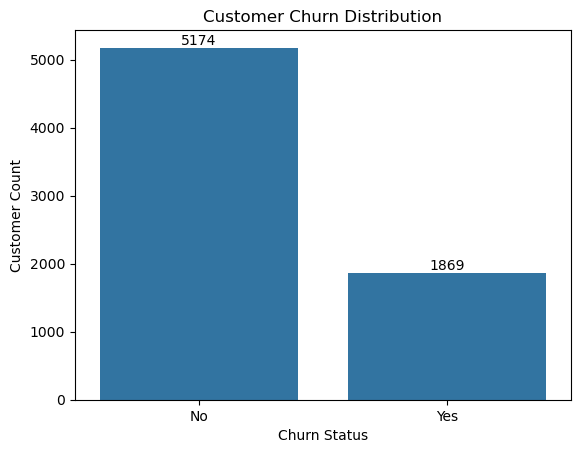

In [94]:
ax = sns.countplot(x = 'Churn', data = df)

ax.bar_label(ax.containers[0])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")
plt.savefig(r"C:\Users\saksh\Documents\Data Analyst\EDA Projects\Customer Churn Analysis\images\churn_distribution.png", bbox_inches='tight')
plt.show()

Overall Churn Rate (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


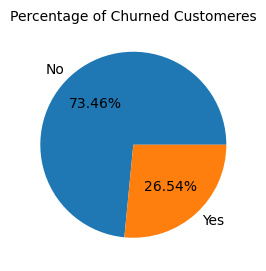

In [29]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customeres", fontsize = 10)
plt.show()

***From the given pie chart we can conclude that overall churn rate is ~26%, indicating moderate customer attrition.***

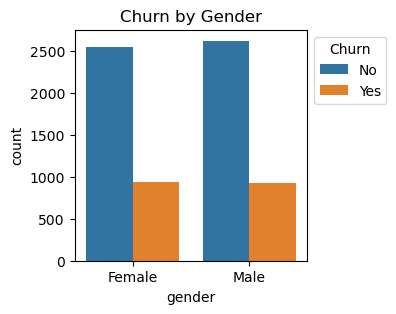

In [40]:
plt.figure(figsize = (3,3))
sns.countplot(x = "gender", data = df, hue = "Churn")
plt.title("Churn by Gender")
plt.legend(title='Churn', bbox_to_anchor = (1,1))
plt.show()

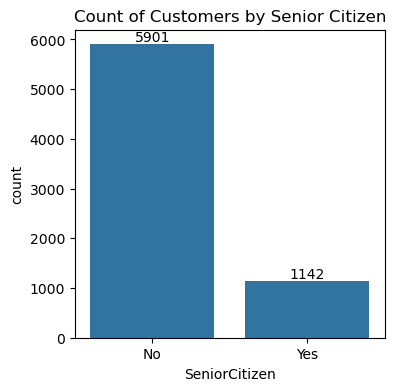

In [31]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "SeniorCitizen", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Senior Citizen")
plt.show()

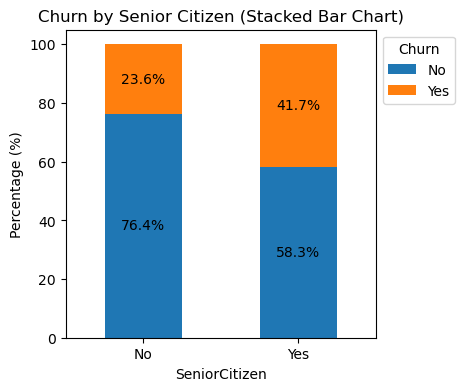

In [33]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

# Plot
fig, ax = plt.subplots(figsize=(4, 4))  # Adjust figsize for better visualization

# Plot the bars
total_counts.plot(kind='bar', stacked=True, ax=ax, color=['#1f77b4', '#ff7f0e'])  # Customize colors if desired

# Add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', ha='center', va='center')

plt.title('Churn by Senior Citizen (Stacked Bar Chart)')
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor = (1,1))  # Customize legend location

plt.show()

***Comparative a greater percentage of people in senior citizen category have churned.***

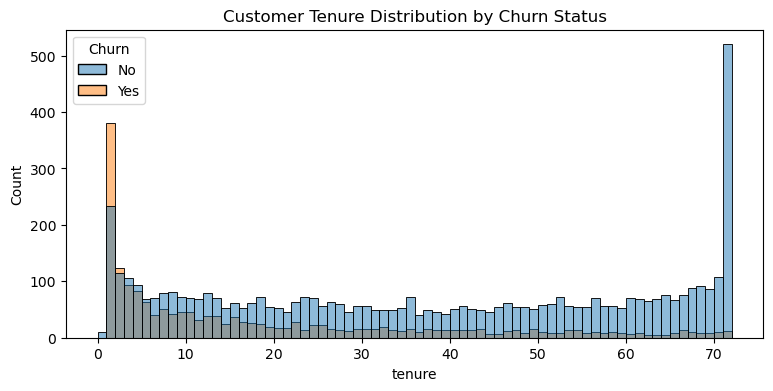

In [87]:
plt.figure(figsize= (9,4))
sns.histplot(x = "tenure", data=df, bins = 72, hue = "Churn")
plt.title("Customer Tenure Distribution by Churn Status")
plt.savefig(r"C:\Users\saksh\Documents\Data Analyst\EDA Projects\Customer Churn Analysis\images\tenure_vs_churn.png", bbox_inches='tight')
plt.show()

***People who have used our services for a long time have stayed and people who have used our services #1 or 2 months have churned.***

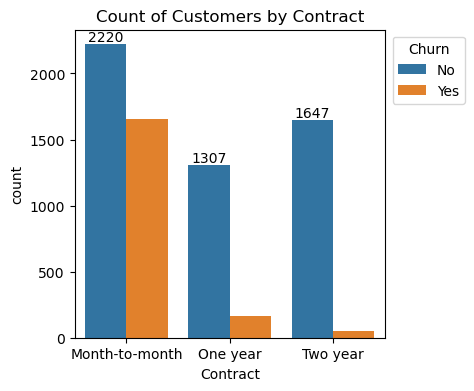

In [88]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x = "Contract", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.legend(title='Churn', bbox_to_anchor = (1.28,1))
plt.savefig(r"C:\Users\saksh\Documents\Data Analyst\EDA Projects\Customer Churn Analysis\images\contract_vs_churn.png", bbox_inches='tight')
plt.show()

***People who have month-to-month contract are likely to churn from those who have 1 or 2 years or contract.***

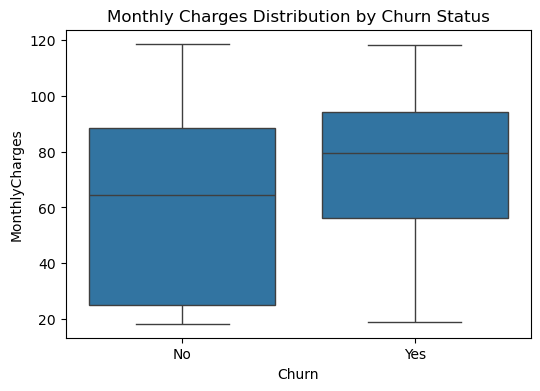

In [85]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges Distribution by Churn Status")
plt.savefig(r"C:\Users\saksh\Documents\Data Analyst\EDA Projects\Customer Churn Analysis\images\monthly_charges_vs_churn.png", bbox_inches='tight')
plt.show()

***Customers who churn generally have higher monthly charges than those who stay, indicating that higher pricing is associated with increased churn likelihood.***

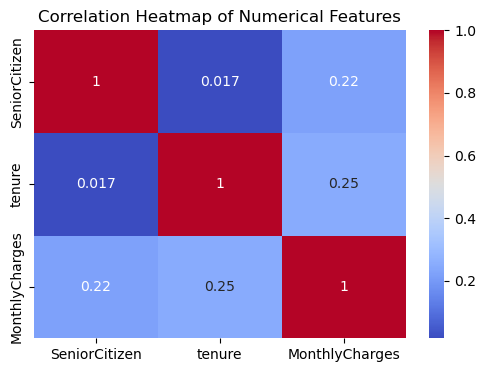

In [74]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

***The heatmap indicates low correlations among the numerical features, suggesting that tenure, MonthlyCharges, and SeniorCitizen are largely independent and do not strongly influence each other linearly.***

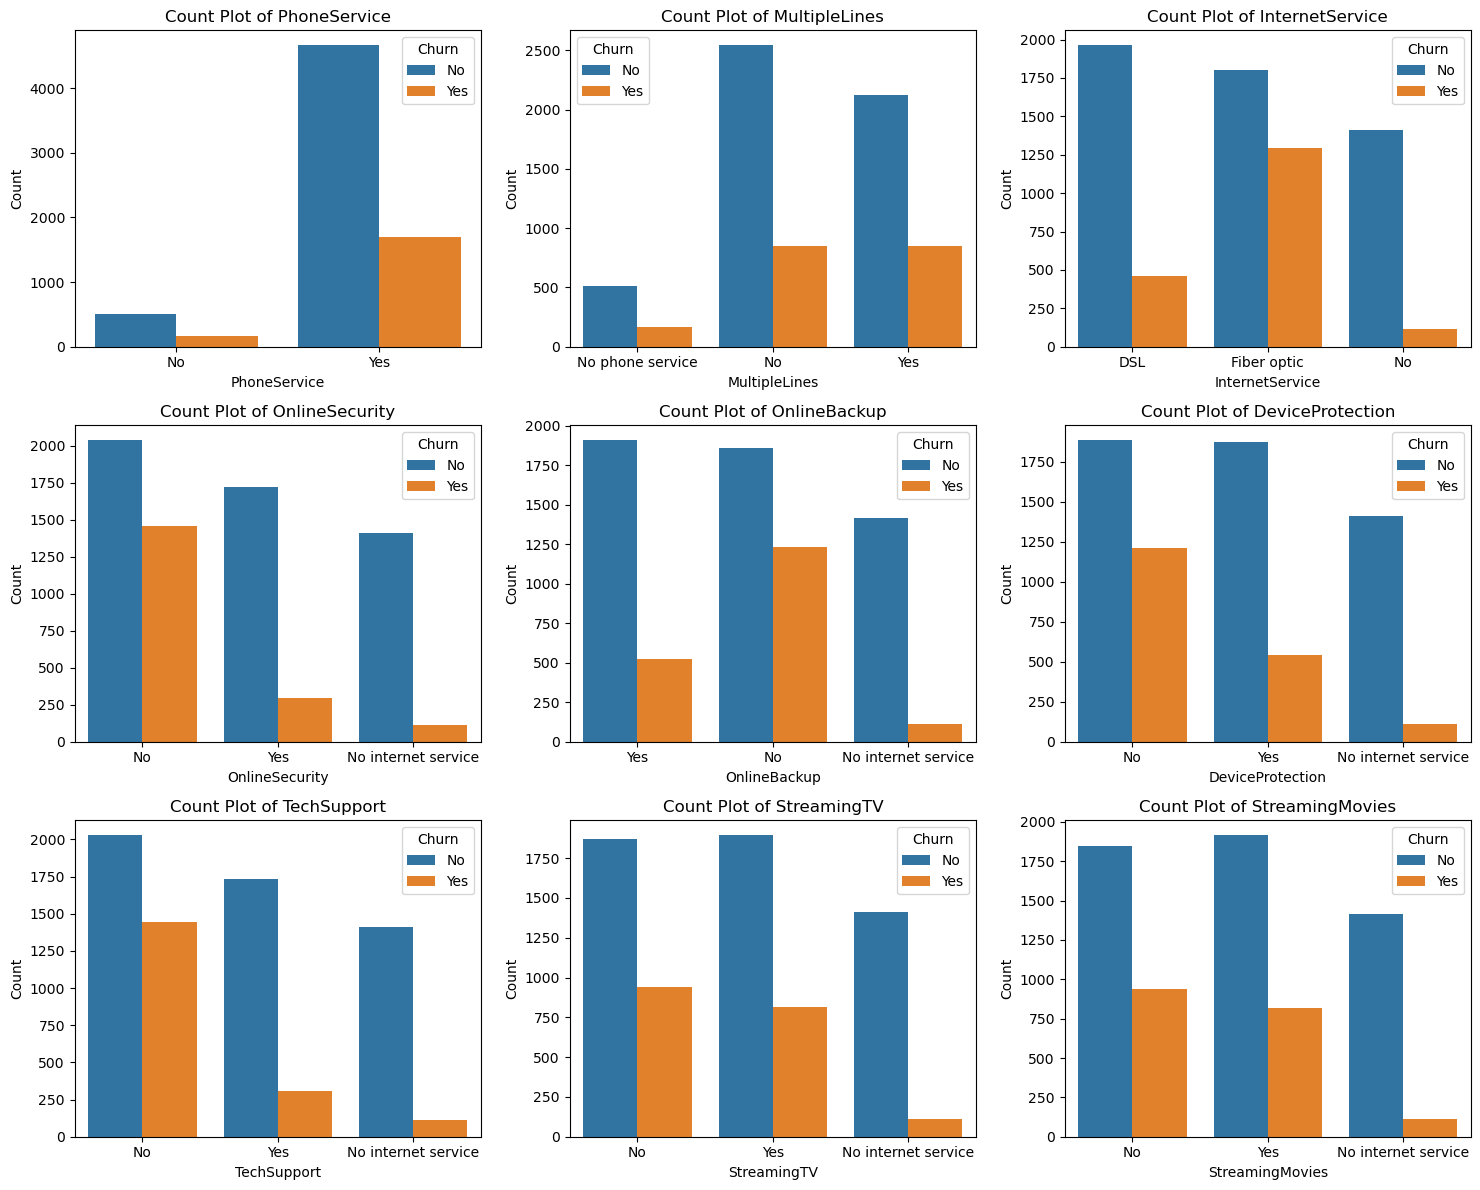

In [54]:
columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Number of columns for the subplot grid (you can change this)
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols  # Calculate number of rows needed

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))  # Adjust figsize as needed

# Flatten the axes array for easy iteration (handles both 1D and 2D arrays)
axes = axes.flatten()

# Iterate over columns and plot count plots
for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df["Churn"])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

***The majority of customers who do not churn tend to have services like PhoneService, InternetService (particularly DSL), and OnlineSecurity enabled. For services like OnlineBackup, TechSupport, and StreamingTV, churn rates are noticeably higher when these services are not used or are unavailable.***

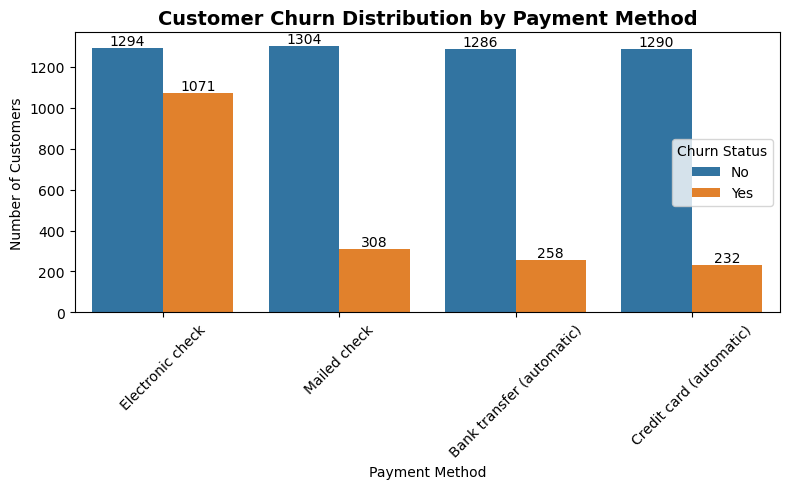

In [86]:
plt.figure(figsize = (8,5))
ax = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")

# Add labels professionally
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution by Payment Method", fontsize=14, fontweight='bold')
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.legend(title='Churn Status')
plt.savefig(r"C:\Users\saksh\Documents\Data Analyst\EDA Projects\Customer Churn Analysis\images\payment_menthod_vs_churn.png", bbox_inches='tight')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

***Customers using Electronic Check as a payment method exhibit the highest churn rate compared to other payment methods, indicating potential dissatisfaction or trust-related concerns with this payment option.***

## 🧾 Final Conclusion

The analysis reveals that customer churn is primarily influenced by contract type, tenure, monthly charges, and payment method. Customers with month-to-month contracts, shorter tenure, and higher monthly charges are significantly more likely to churn. Additionally, customers using electronic check and those not subscribed to value-added services such as OnlineSecurity and TechSupport show higher churn tendencies.

Long-term customers with yearly contracts and multiple service subscriptions demonstrate stronger retention, indicating that service engagement and long-term commitment play a crucial role in reducing churn.

## 💡 Business Recommendations
- Promote long-term contracts to improve customer retention
- Encourage secure payment methods instead of electronic checks
- Improve onboarding experience for customers in the first year
- Offer bundled services (OnlineSecurity, TechSupport) to reduce churn risk